### 1. Title
### Mini Project #1: Spatial and Temporal Analysis of Crime Incidents in Little Rock, Arkansas (2020–2025)


##### This project analyzes reported crime incidents in Little Rock, Arkansas using a CSV dataset containing incident records, offense attributes, and geographic coordinates. The project develops a reproducible GIS programming workflow beginning with tabular data cleaning and exploratory analysis in Python, followed by spatial conversion to a GeoDataFrame and publication to ArcGIS Online using the ArcGIS Python API. A web map is then created and saved from the notebook, and the published point layer is symbolized as a heat map in ArcGIS Online to highlight areas of higher incident concentration.

### 2. Problem statement

Crime incidents are not randomly distributed in either space or time. Understanding where incidents cluster and how they vary by year, offense type, and time of day can help reveal important urban patterns. This project addresses the following question:

What spatial and temporal patterns are evident in reported crime incidents in Little Rock, Arkansas from 2020 through 2025, and where are the strongest concentrations of incidents located?

This question is appropriate for GIS analysis because the data contain both timestamps and geographic coordinates. The temporal component supports yearly and hourly summaries, while the spatial component supports point mapping and web-based heat map visualization. The project also demonstrates how a processed GeoDataFrame can be published to ArcGIS Online and incorporated into a web map using the ArcGIS Python API.

### 3. Data source

The main dataset used in this project is Little_Rock_Crime_2020_2026.csv, which contains incident-level crime records with fields such as incident date, offense description, district or location information, and geographic coordinates. Because the original source is a CSV rather than a native GIS file, the records must first be read into a Pandas DataFrame and then converted into a GeoDataFrame using the latitude and longitude fields.

### 4. Import libraries


In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import getpass
from arcgis.gis import GIS

### 5. Read the raw CSV

In [2]:
crime_df_raw = pd.read_csv(r"D:\WesternMichiganUni\GIS_Programming\miniproject\Little_Rock_Crime_2020_2026.csv")

print("Shape:", crime_df_raw.shape)
print(crime_df_raw.columns)
crime_df_raw.head()

Shape: (81629, 15)
Index(['INCIDENT_DATE', 'INCIDENT_NUMBER', 'LOCATION_DISTRICT', 'OFFENSE_CODE',
       'OFFENSE_DESCRIPTION', 'WEAPON_TYPE', 'INCIDENT_LOCATION', 'CITY',
       'STATE', 'ZIP', 'LATITUDE', 'LONGITUDE', 'Location 1', 'Offense Status',
       'Year'],
      dtype='object')


,INCIDENT_DATE,INCIDENT_NUMBER,LOCATION_DISTRICT,OFFENSE_CODE,OFFENSE_DESCRIPTION,WEAPON_TYPE,INCIDENT_LOCATION,CITY,STATE,ZIP,LATITUDE,LONGITUDE,Location 1,Offense Status,Year
0,01/19/2026 11:20:00 PM,2026-008338,61.0,23H,ALL OTHER LARCENY,NaN,7200 W 12TH ST,LITTLE ROCK,AR,72204,34.742472,-92.355167,"(34.742472, -92.355167)",OP,2026
1,01/19/2026 10:18:00 PM,2026-008322,52.0,13A,AGGRAVATED ASSAULT,"PERSONAL WEAPONS (HANDS, FISTS, ETC)",1508 W 26TH ST,LITTLE ROCK,AR,72206,34.724040,-92.290150,"(34.72404, -92.29015)",OP,2026
2,01/19/2026 10:09:00 PM,2026-008320,82.0,220,BURGLARY/B&E,NaN,7123 INTERSTATE 30,LITTLE ROCK,AR,72209,34.680708,-92.312983,"(34.680708, -92.312983)",OP,2026
3,01/19/2026 04:47:00 PM,2026-008223,51.0,23H,ALL OTHER LARCENY,NaN,1 CHILDRENS WAY,LITTLE ROCK,AR,72202,34.742747,-92.292790,"(34.742747, -92.29279)",OP,2026
4,01/19/2026 04:43:00 PM,2026-008221,82.0,23F,THEFT FROM MOTOR VEHICLE,NaN,6401 BASELINE RD,LITTLE ROCK,AR,72209,34.669322,-92.349396,"(34.669322, -92.349396)",OP,2026


### 6. Assess missing values

In [3]:
null_counts = crime_df_raw.isnull().sum().sort_values(ascending=False)
null_percent = (crime_df_raw.isnull().sum() / len(crime_df_raw) * 100).sort_values(ascending=False)

null_summary = pd.DataFrame({
    "Null Count": null_counts,
    "Null Percent": null_percent
})

null_summary

,Null Count,Null Percent
WEAPON_TYPE,61541,75.391099
LONGITUDE,5192,6.360485
LATITUDE,5192,6.360485
Location 1,5192,6.360485
LOCATION_DISTRICT,113,0.138431
Offense Status,28,0.034302
INCIDENT_DATE,0,0.000000
INCIDENT_LOCATION,0,0.000000
OFFENSE_DESCRIPTION,0,0.000000
OFFENSE_CODE,0,0.000000


### 7. Clean the time field and remove 2026

The year 2026 is excluded because it does not contain a complete reporting period. Retaining an incomplete year would distort annual comparisons and could create misleading trends in the yearly charts. Restricting the analysis to 2020–2025 improves temporal comparability.

In [4]:
crime_df = crime_df_raw.copy()

crime_df["INCIDENT_DATE"] = pd.to_datetime(crime_df["INCIDENT_DATE"], errors="coerce")
crime_df["Year"] = crime_df["INCIDENT_DATE"].dt.year

# remove incomplete year
crime_df = crime_df[crime_df["Year"] != 2026].copy()

print(sorted(crime_df["Year"].dropna().unique()))
print("Rows after removing 2026:", len(crime_df))

C:\Users\tangi\AppData\Local\Temp\ipykernel_33340\4068742899.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  crime_df["INCIDENT_DATE"] = pd.to_datetime(crime_df["INCIDENT_DATE"], errors="coerce")


[np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]
Rows after removing 2026: 81097


### 8. Remove null coordinates and obvious outliers

Records without usable coordinates are removed because they cannot be converted into point features.

In [5]:
crime_df = crime_df.dropna(subset=["LATITUDE", "LONGITUDE"]).copy()

# rough coordinate filter to remove obvious outliers
crime_df = crime_df[
    crime_df["LATITUDE"].between(34.55, 34.85) &
    crime_df["LONGITUDE"].between(-92.55, -92.15)
].copy()

print("Rows after removing missing / invalid coordinates:", len(crime_df))

Rows after removing missing / invalid coordinates: 74806


### 9. Filter to the Little Rock study area

In [6]:
crime_df["CITY_CLEAN"] = crime_df["CITY"].astype(str).str.upper().str.strip()
crime_df["STATE_CLEAN"] = crime_df["STATE"].astype(str).str.upper().str.strip()

crime_df = crime_df[
    crime_df["CITY_CLEAN"].str.contains("LITTLE ROCK", na=False) |
    (crime_df["CITY_CLEAN"] == "LR")
].copy()

crime_df = crime_df[crime_df["STATE_CLEAN"] == "AR"].copy()

print("Rows after city/state filtering:", len(crime_df))

Rows after city/state filtering: 74806


### 10. Create derived indicators

Derived variables are created to support temporal analysis. These fields allow the project to examine when incidents are reported and to move beyond simple point mapping toward a broader interpretation of crime patterns.

In [7]:
crime_df["Month"] = crime_df["INCIDENT_DATE"].dt.month
crime_df["Month_Name"] = crime_df["INCIDENT_DATE"].dt.month_name()
crime_df["Hour"] = crime_df["INCIDENT_DATE"].dt.hour
crime_df["DayOfWeek"] = crime_df["INCIDENT_DATE"].dt.day_name()
crime_df["Is_Weapon_Reported"] = crime_df["WEAPON_TYPE"].notna()

### 11. Create a simplified offense classification

Detailed offense descriptions can be too fragmented for interpretation. Grouping related categories into broader classes makes the dataset easier to summarize and discuss.

In [8]:
def classify_offense(offense):
    offense = str(offense).upper()
    if "ASSAULT" in offense:
        return "Assault"
    elif "LARCENY" in offense or "THEFT" in offense:
        return "Theft"
    elif "BURGLARY" in offense:
        return "Burglary"
    elif "ROBBERY" in offense:
        return "Robbery"
    elif "MOTOR VEHICLE" in offense:
        return "Vehicle Crime"
    elif "RAPE" in offense or "SEX" in offense:
        return "Sex Offense"
    else:
        return "Other"

crime_df["Offense_Group"] = crime_df["OFFENSE_DESCRIPTION"].apply(classify_offense)

### 12. Convert to a GeoDataFrame
The cleaned table is converted into a GeoDataFrame using longitude and latitude. This is the key transition from tabular analysis to spatial analysis and is required for mapping, exporting, and publishing the final dataset.

In [9]:
crime_gdf = gpd.GeoDataFrame(
    crime_df,
    geometry=gpd.points_from_xy(crime_df["LONGITUDE"], crime_df["LATITUDE"]),
    crs="EPSG:4326"
)

print(crime_gdf.shape)
crime_gdf.head()

(74806, 24)


,INCIDENT_DATE,INCIDENT_NUMBER,LOCATION_DISTRICT,OFFENSE_CODE,OFFENSE_DESCRIPTION,WEAPON_TYPE,INCIDENT_LOCATION,CITY,STATE,ZIP,...,Year,CITY_CLEAN,STATE_CLEAN,Month,Month_Name,Hour,DayOfWeek,Is_Weapon_Reported,Offense_Group,geometry
532,2025-12-31 23:01:00,2025-161160,53.0,23H,ALL OTHER LARCENY,NaN,2009 S WOODROW ST,LITTLE ROCK,AR,72204,...,2025,LITTLE ROCK,AR,12,December,23,Wednesday,False,Theft,POINT (-92.30588 34.73199)
533,2025-12-31 21:11:00,2025-161106,52.0,13A,AGGRAVATED ASSAULT,FIREARM,1624 BROADWAY ST,LITTLE ROCK,AR,72206,...,2025,LITTLE ROCK,AR,12,December,21,Wednesday,True,Assault,POINT (-92.27864 34.73349)
534,2025-12-31 20:05:00,2025-161075,82.0,23H,ALL OTHER LARCENY,NaN,6420 BASELINE RD,LITTLE ROCK,AR,72209,...,2025,LITTLE ROCK,AR,12,December,20,Wednesday,False,Theft,POINT (-92.33235 34.66898)
535,2025-12-31 18:52:00,2025-161039,82.0,13A,AGGRAVATED ASSAULT,KNIFE/CUTTING INSTRUMENT,8107 GEYER SPRINGS RD,LITTLE ROCK,AR,72209,...,2025,LITTLE ROCK,AR,12,December,18,Wednesday,True,Assault,POINT (-92.34351 34.67612)
536,2025-12-31 18:18:00,2025-161025,72.0,13A,AGGRAVATED ASSAULT,"PERSONAL WEAPONS (HANDS, FISTS, ETC)",11501 FINANCIAL CENTRE PKY,LITTLE ROCK,AR,72211,...,2025,LITTLE ROCK,AR,12,December,18,Wednesday,True,Assault,POINT (-92.40172 34.74608)


### 13. Add county boundary context

In [10]:
county_gdf = gpd.read_file(r"D:\WesternMichiganUni\GIS_Programming\miniproject\COUNTY_BOUNDARY.shp")
print(county_gdf.columns)

Index(['OBJECTID', 'COUNTY', 'STATEFIPS', 'COUNTYFIPS', 'POP1900', 'POP1910',
       'POP1920', 'POP1930', 'POP1940', 'POP1950', 'POP1960', 'POP1970',
       'POP1980', 'POP1990', 'POP2000', 'POP2010', 'POP2020', 'EFF_DATE',
       'REV_DATE', 'REV_TYPE', 'SQ_MILES', 'Shape_STAr', 'Shape_STLe',
       'geometry'],
      dtype='object')


#### The county boundary is used here as a geographic reference layer and an additional spatial filter. Since the boundary is county-based rather than city-based, this step is best understood as a contextual refinement rather than a perfect Little Rock municipal clip.

In [11]:
pulaski_gdf = county_gdf[county_gdf["COUNTY"].str.upper() == "PULASKI"].copy()
pulaski_gdf = pulaski_gdf.to_crs(crime_gdf.crs)

In [12]:
crime_gdf = crime_gdf.drop(columns=["index_left", "index_right"], errors="ignore")
pulaski_gdf = pulaski_gdf.drop(columns=["index_left", "index_right"], errors="ignore")

crime_gdf = gpd.clip(crime_gdf, pulaski_gdf)

print("Rows after county clip:", len(crime_gdf))

Rows after county clip: 74806


### 14. Exploratory plots
Crime incidents by year
This chart summarizes crime incidents by year for 2020–2025 after the incomplete 2026 records were removed. The figure provides a cleaner temporal comparison because only more complete reporting periods are included.

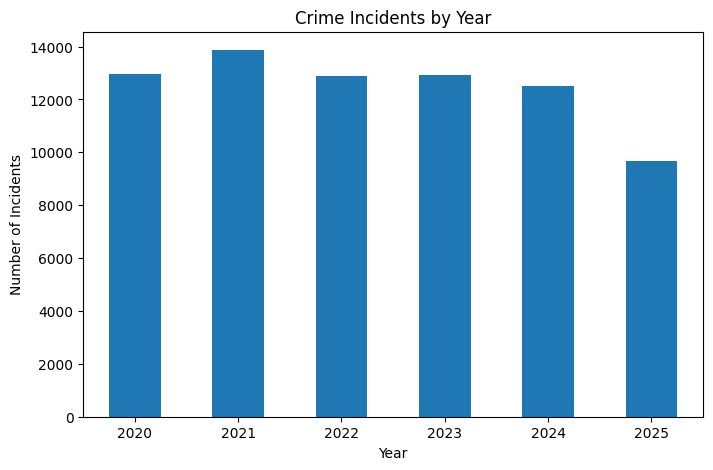

In [13]:
year_counts = crime_gdf["Year"].value_counts().sort_index()

plt.figure(figsize=(8,5))
year_counts.plot(kind="bar")
plt.title("Crime Incidents by Year")
plt.xlabel("Year")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=0)
plt.show()

#### Top 10 offense descriptions
This figure identifies the most frequently reported incident categories and helps show which offense types dominate the dataset.

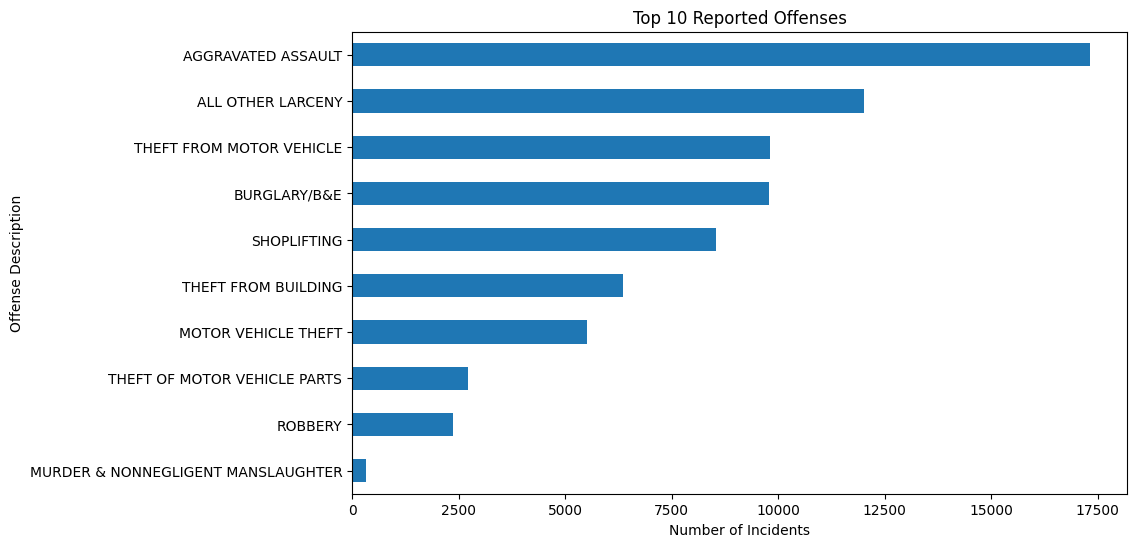

In [14]:
top_offenses = crime_gdf["OFFENSE_DESCRIPTION"].value_counts().head(10)

plt.figure(figsize=(10,6))
top_offenses.sort_values().plot(kind="barh")
plt.title("Top 10 Reported Offenses")
plt.xlabel("Number of Incidents")
plt.ylabel("Offense Description")
plt.show()

#### Crime incidents by hour
This chart highlights how incidents vary throughout the day and adds a behavioral time dimension to the analysis.

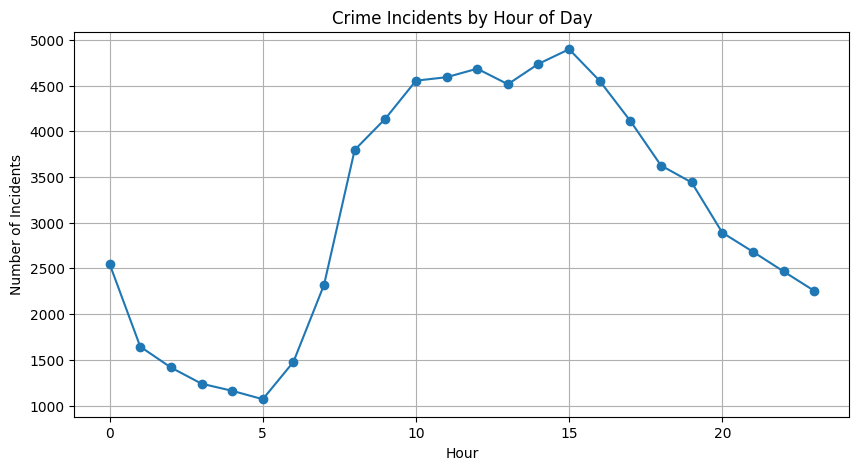

In [15]:
hour_counts = crime_gdf["Hour"].value_counts().sort_index()

plt.figure(figsize=(10,5))
hour_counts.plot(kind="line", marker="o")
plt.title("Crime Incidents by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Incidents")
plt.grid(True)
plt.show()

#### Simplified offense groups
This figure shows broader thematic patterns by reducing the complexity of the detailed offense field.

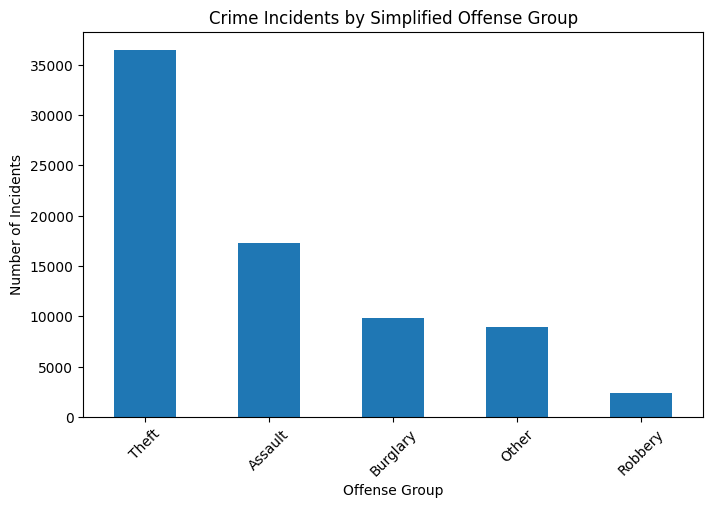

In [16]:
group_counts = crime_gdf["Offense_Group"].value_counts()

plt.figure(figsize=(8,5))
group_counts.plot(kind="bar")
plt.title("Crime Incidents by Simplified Offense Group")
plt.xlabel("Offense Group")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=45)
plt.show()

### 15. Static map
The static map provides an overview of incident distribution in the study area. The county boundary is used as contextual background so the point distribution can be interpreted within a recognizable geographic frame.

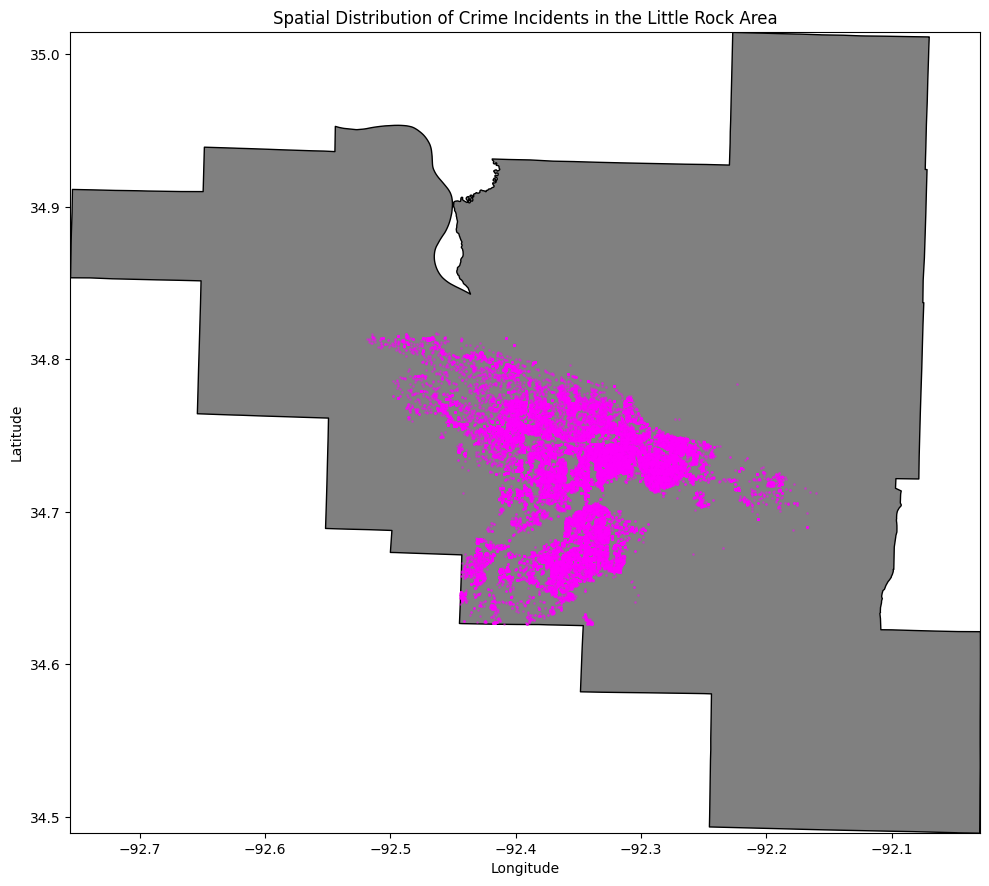

In [19]:
fig, ax = plt.subplots(figsize=(10,10))

pulaski_gdf.plot(
    ax=ax,
    color="gray",
    edgecolor="black",
    linewidth=1
)

crime_gdf.plot(
    ax=ax,
    color="magenta",
    markersize=1,
    alpha=0.35
)

minx, miny, maxx, maxy = pulaski_gdf.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_title("Spatial Distribution of Crime Incidents in the Little Rock Area")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

### 16. Export the cleaned GeoDataFrame
The cleaned GeoDataFrame is exported to GeoJSON so it can be uploaded and published to ArcGIS Online as a hosted feature layer.


In [20]:
crime_gdf.to_file("little_rock_crime_2020_2025.geojson", driver="GeoJSON")

### 17. Connect to ArcGIS Online with the ArcGIS Python API

In [21]:
def agol_login():
    print("Log in to ArcGIS Online")
    username = input("USERNAME: ")
    password = getpass.getpass("PASSWORD: ")
    gis = GIS("https://www.arcgis.com", username, password)
    print("Logged in as:", gis.properties.user.username)
    return gis

gis = agol_login()

Log in to ArcGIS Online
Logged in as: tangiha.majumder@wmich.edu


### 18. Publish the cleaned point layer

In [22]:
item_properties = {
    "title": "Little_Rock_Crime_2020_To_2025",
    "description": "Cleaned crime incidents for Little Rock mini project, published from Jupyter Notebook.",
    "tags": "Little Rock, crime, ArcGIS Online, GIS Programming, WMU",
    "type": "GeoJson"
}

geojson_item = gis.content.add(
    item_properties=item_properties,
    data="little_rock_crime_2020_2025.geojson"
)

published_layer = geojson_item.publish()
published_layer

C:\Users\tangi\AppData\Roaming\Python\Python313\site-packages\IPython\core\interactiveshell.py:3701: DeprecatedWarning: add is deprecated as of 2.3.0 and has been removed in 3.0.0. Use `Folder.add()` instead.
  exec(code_obj, self.user_global_ns, self.user_ns)
C:\Users\tangi\AppData\Roaming\Python\Python313\site-packages\arcgis\graph\data_model_types.py:68: PydanticDeprecatedSince20: Support for class-based `config` is deprecated, use ConfigDict instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  class GraphProperty(BaseModel):
C:\Users\tangi\AppData\Roaming\Python\Python313\site-packages\arcgis\graph\data_model_types.py:271: PydanticDeprecatedSince20: Support for class-based `config` is deprecated, use ConfigDict instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  class FieldIndex(BaseModel):
C:\Users\tangi\Ap

<Item title:"Little_Rock_Crime_2020_To_2025" type:Feature Layer Collection owner:tangiha.majumder@wmich.edu>

### 19. Create a web map in the notebook

In [30]:
crime_map = gis.map("Little Rock, Arkansas")
crime_map.content.add(published_layer)
crime_map

Map()

In [26]:
webmap_item = crime_map.save({
    "title": "Little Rock Crime Web Map",
    "snippet": "Web map created from Jupyter Notebook using ArcGIS Python API",
    "tags": ["Little Rock", "Crime", "ArcGIS Online", "WMU"],
    "description": "Interactive web map for Mini Project #1"
})
webmap_item

<Item title:"Little Rock Crime Web Map" type:Web Map owner:tangiha.majumder@wmich.edu>

In [27]:
import arcgis
print(arcgis.__version__)

2.4.2


In [29]:
crime_map.content.add(published_layer)